# 03 · Index design: the PREPARE stage

**FDE Academy · Accelerator track · Retrieval, RAG and Evals · Lab notebook 3 of 8**

You change how the index is built and measure what each decision bounds: chunking against boundary loss, freshness without a full rebuild, permission filters that do not leak, and contextual retrieval reproduced on this corpus.

| How to run | What it needs | Runs before | Runs after |
|---|---|---|---|
| Run All, top to bottom. Every cell executes offline in under a minute or two. | Python 3.10 or later with numpy, pandas, matplotlib and scikit-learn. `boto3` and `tiktoken` are optional and detected automatically. | Notebook 02. | Notebook 04, which tunes what happens at query time over the index you build here. |

Two documents in the corpus are internal (a Vega Dynamics data sheet and Halden release notes) with access lists, so the permission demo has real rows to protect.

## Where this sits on the pipeline

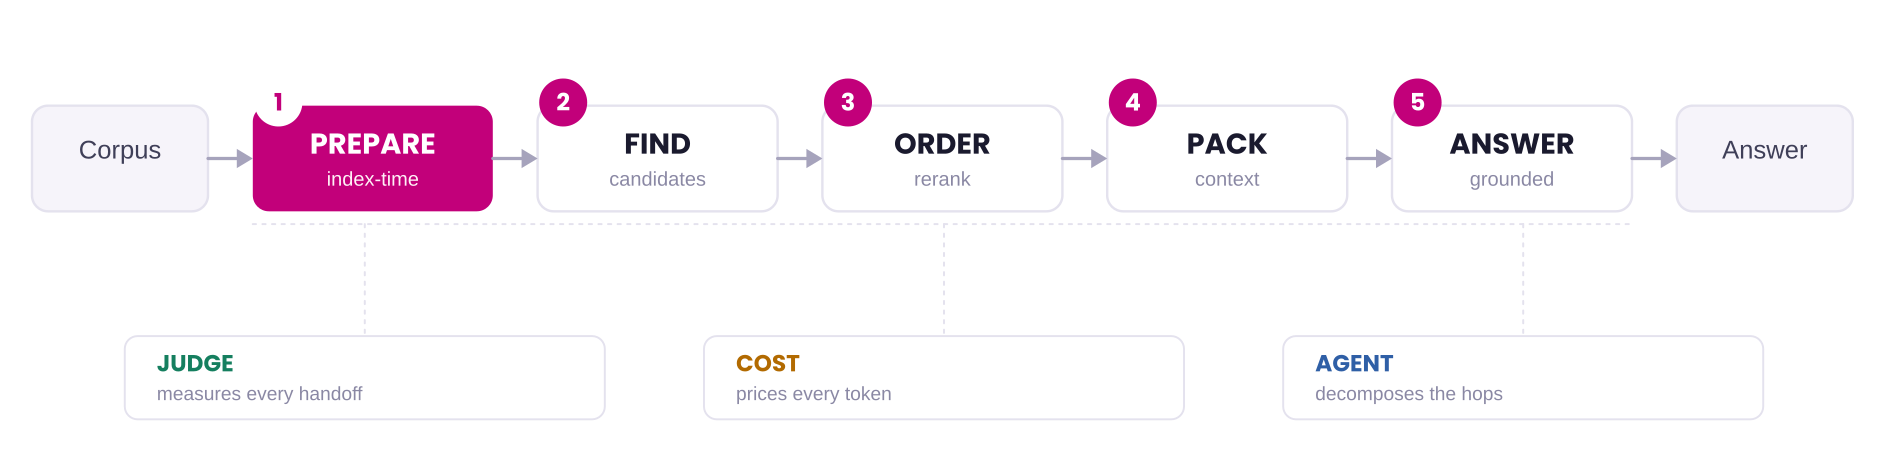

*Everything in this notebook happens offline and rarely, and it sets the outer limit of what any query can ever find.*

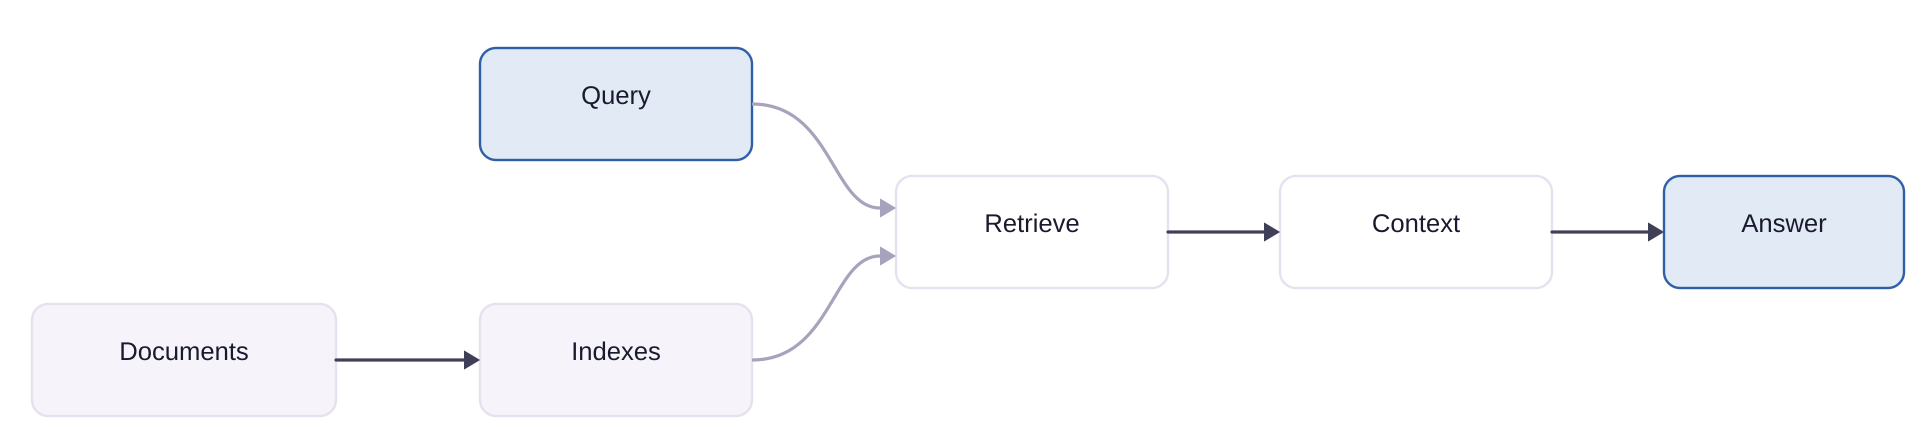

*They meet at Retrieve. Everything upstream is a one-time cost, everything downstream is per query.*

## 1 · Index-time is a pipeline, and it is validated before it goes live

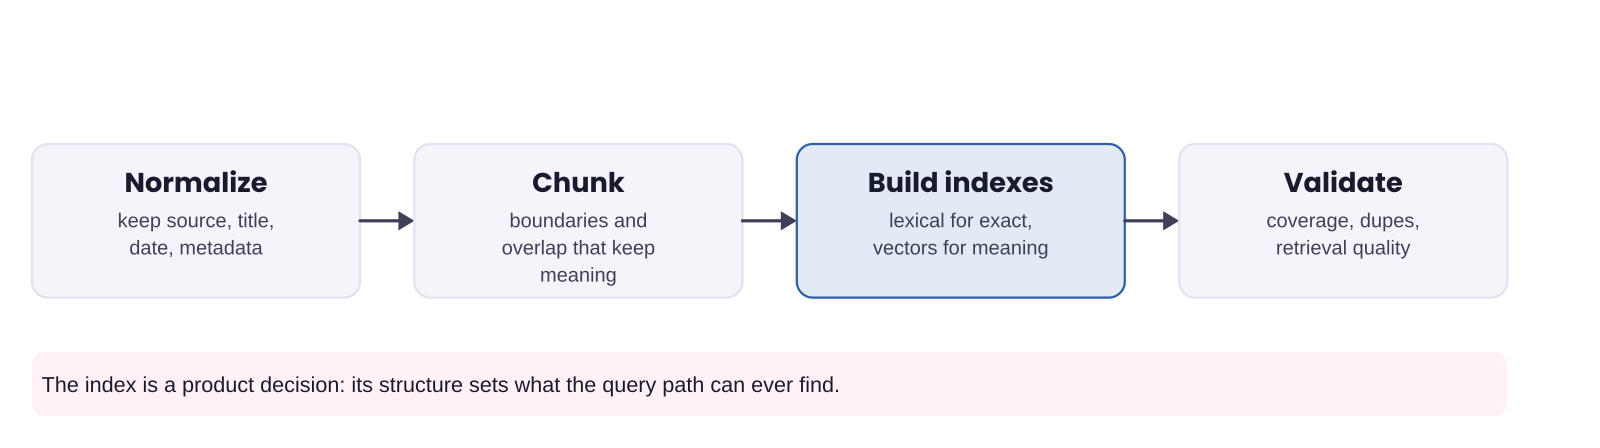

*The validate step is the one teams skip. It runs the benchmark against the new index before any traffic is routed to it.*

In [1]:
# One-click setup. The notebook runs offline on numpy, pandas, matplotlib, scikit-learn and sqlite3.
# `ragkit` ships in the same folder as this notebook.
import sys, os
from pathlib import Path
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ragkit").is_dir():
        sys.path.insert(0, str(p)); break
import numpy as np, pandas as pd
import ragkit as rk
from ragkit import table, verdict_style, bars, lines, decision
rk.palette.style()
pd.set_option("display.width", 160)
print("ragkit", rk.__version__, "| provider:", rk.config()["provider"], "| tokenizer:", rk.TOKENIZER)

ragkit 0.1.0 | provider: mock | tokenizer: tiktoken cl100k_base


In [2]:
store = rk.Store(); questions = rk.load(store); docs = store.docs()
tuning = [q for q in questions if not q.frozen]

def build(chunker="structural", version="v1", carry_title=True, n_components=48, random_state=0, chunks=None):
    """Chunk, index (lexical and dense), wrap in a retriever. Returns (chunks, retriever)."""
    if chunks is None:
        chunks = rk.chunk_corpus(docs, chunker, version) if chunker != "structural_raw" else [c for d in docs for c in rk.structural(d, carry_title=False, version=version)]
    store.add_chunks(chunks, version, chunker=chunker, embedder=f"lsa{n_components}_rs{random_state}")
    emb = rk.LSAEmbedder(n_components, random_state).fit([c.text for c in chunks])
    return chunks, rk.Retriever(store, chunks, emb, name=version)

def validate(chunks, retriever, qs, k=10):
    """The pre-live check: boundary loss and full-chain recall on the tuning slice."""
    loss = sum(1 for q in qs for s in rk.gold_chunk_sets(q, chunks) if len(s) == 0)
    df = rk.run_benchmark(rk.RunConfig("validate", mode="hybrid", n_pool=50, k=k), retriever, rk.MockGenerator(), qs, chunks)
    return {"chunks": len(chunks), "boundary_loss_spans": loss, f"full_chain@{k}": round(float(df["full_chain@k"].mean()), 3), "correct": round(float(df["correct"].mean()), 3)}

chunks_v1, ret_v1 = build("structural", "v1")
report = validate(chunks_v1, ret_v1, tuning)
print("validation report for v1:", report)
if report["boundary_loss_spans"] == 0 and report["full_chain@10"] >= 0.8:
    store.set_live("v1"); print("v1 passed validation and is now live")
table(pd.DataFrame(store.versions()), "index_versions after the first build")

validation report for v1: {'chunks': 64, 'boundary_loss_spans': 0, 'full_chain@10': 0.857, 'correct': 0.889}
v1 passed validation and is now live


version,chunker,embedder,created_seq,live
v1,structural,lsa48_rs0,1,1


| Index-time decision | What it bounds for every later query | Where you see it fail |
|---|---|---|
| How documents are split into chunks | Whether a fact exists as a single retrievable unit at all. | Boundary loss: a gold span with no carrying chunk, measured in section 2. |
| Which metadata survives into the chunk store | Whether you can filter by date or tenant, and cite a source. | The interim-CEO article beating the real one, from notebook 01. |
| Which embedding model built the vectors | Which vectors can be compared with which. | The mixed-vectors outage in section 6. |
| Whether a lexical index is built alongside the vectors | Whether exact identifiers are reachable. | Notebook 04's identifier-blur failure. |
| Whether the index was validated before going live | Whether you find out from the benchmark or from users. | The validation report above, which gates `set_live`. |

## 2 · Chunking strategies, measured rather than guessed

Every strategy below is scored on the same benchmark. Boundary loss counts gold spans that no chunk carries whole. Full-chain recall is the multi-hop number.

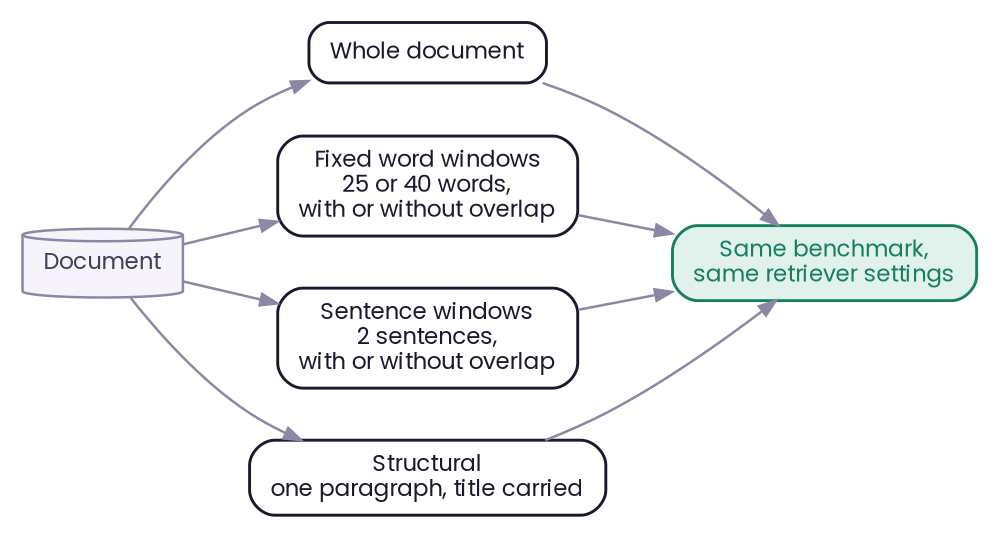

*Eight strategies, one scoreboard.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    d[("Document")]
    w["Whole document"]
    f["Fixed word windows<br/>25 or 40 words,<br/>with or without overlap"]
    s["Sentence windows<br/>2 sentences,<br/>with or without overlap"]
    st["Structural<br/>one paragraph, title carried"]
    m["Same benchmark,<br/>same retriever settings"]
    d --> w
    d --> f
    d --> s
    d --> st
    w --> m
    f --> m
    s --> m
    st --> m
    class d data
    class m ok
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

chunker,chunks,avg words,boundary loss spans,full_chain@5,full_chain@10
whole_doc,30,44.600,0,0.889,1.000
fixed_25,68,19.700,1,0.444,0.778
fixed_25_ov8,79,21.900,1,0.556,0.667
fixed_40,47,28.400,0,0.778,0.889
fixed_40_ov12,50,31.500,0,0.778,0.889
sent_2,48,27.900,0,0.778,0.778
sent_2_ov1,56,29.800,0,0.778,0.778
structural,64,28.500,0,0.778,0.889


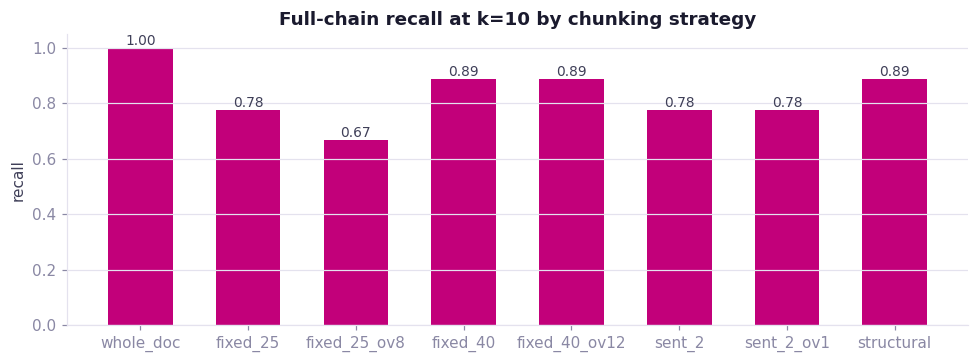

In [3]:
rows = []
systems = {}
for name in rk.CHUNKERS:
    ch, ret = build(name, f"cmp_{name}")
    systems[name] = (ch, ret)
    r = validate(ch, ret, questions, k=5); r10 = validate(ch, ret, questions, k=10)
    texts = {c.chunk_id: c.text for c in ch}
    rows.append({"chunker": name, "chunks": r["chunks"], "avg words": round(np.mean([c.n_words for c in ch]), 1), "boundary loss spans": r["boundary_loss_spans"],
                 "full_chain@5": r["full_chain@5"], "full_chain@10": r10["full_chain@10"]})
cmp = pd.DataFrame(rows)
display(table(cmp, "Chunking strategies on the full benchmark, hybrid retrieval, N=50"))
bars(list(cmp["chunker"]), list(cmp["full_chain@10"]), "Full-chain recall at k=10 by chunking strategy", "recall", fmt="{:.2f}", figsize=(9, 3.4))

Now the two knobs of fixed-size chunking on a grid. The longest gold fact in this corpus is 27 words, which is the number that explains the whole first row.

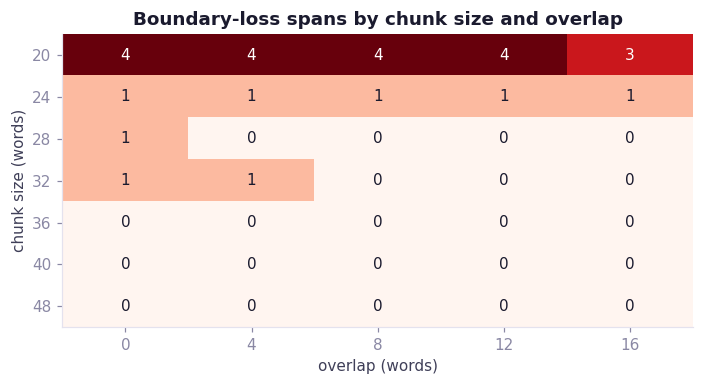

longest gold span: 27 words


In [4]:
sizes, ovs = [20, 24, 28, 32, 36, 40, 48], [0, 4, 8, 12, 16]
grid = np.zeros((len(sizes), len(ovs)), dtype=int)
for i, size in enumerate(sizes):
    for j, ov in enumerate(ovs):
        cc = [c for d in docs for c in rk.fixed_words(d, size, ov)]
        grid[i, j] = sum(1 for q in questions for s in rk.gold_chunk_sets(q, cc) if len(s) == 0)
import matplotlib.pyplot as plt
fig_, ax = plt.subplots(figsize=(6.5, 3.6))
im = ax.imshow(grid, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(ovs))); ax.set_xticklabels(ovs); ax.set_yticks(range(len(sizes))); ax.set_yticklabels(sizes)
ax.set_xlabel("overlap (words)"); ax.set_ylabel("chunk size (words)"); ax.set_title("Boundary-loss spans by chunk size and overlap"); ax.grid(False)
for i in range(len(sizes)):
    for j in range(len(ovs)):
        ax.text(j, i, grid[i, j], ha="center", va="center", color="white" if grid[i, j] >= 2 else rk.palette.INK, fontsize=10)
plt.tight_layout(); plt.show()
longest = max(len(s.split()) for q in questions for _, s in q.gold)
print("longest gold span:", longest, "words")

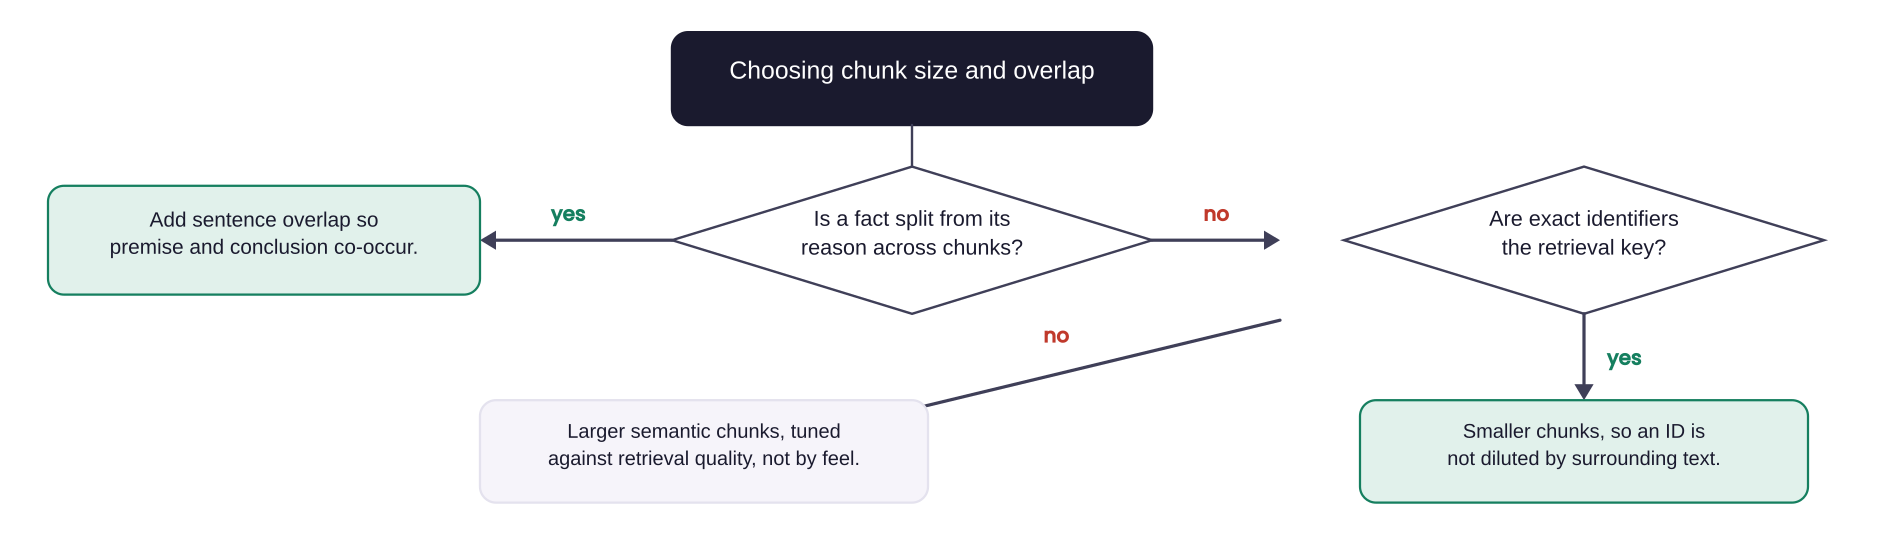

*Own construction. The grid above is the evidence behind each branch.*

| If the grid shows | Then | Because |
|---|---|---|
| Loss at every overlap in a row, as at 20 and 24 words. | Increase chunk size. Overlap cannot help. | A chunk shorter than the fact can never contain the fact, whatever you repeat between neighbours. |
| Loss at overlap 0 that vanishes at overlap 4 to 8, as at 28 and 32 words. | Keep the size and add sentence-level overlap. | A boundary happened to fall inside a fact, and the overlap window repeats the linking words so one chunk carries the whole thought. |
| No loss from 36 words up. | Choose the size by retrieval precision and token cost instead, since recall is no longer the constraint. | Bigger chunks pack more unrelated text into the context per fact retrieved. Notebook 05 measures that cost. |
| Whole documents score highest here, and structural chunking matches the best fixed window with no size to tune. | Prefer document structure when the documents have any, and treat the whole-document result as an artefact of a corpus whose articles average 45 words. | Paragraph boundaries were placed by an author who kept a thought together. Production documents run to thousands of words, where a whole document blows the packing budget that notebook 05 measures. |
| Overlap raised the chunk count and lowered full-chain recall at k=10 for the 25-word window. | Deduplicate near-identical neighbours before packing. Notebook 05. | Overlap manufactures near-duplicate chunks that compete for the same k slots. |

## 3 · Boundary loss, shown on one fact

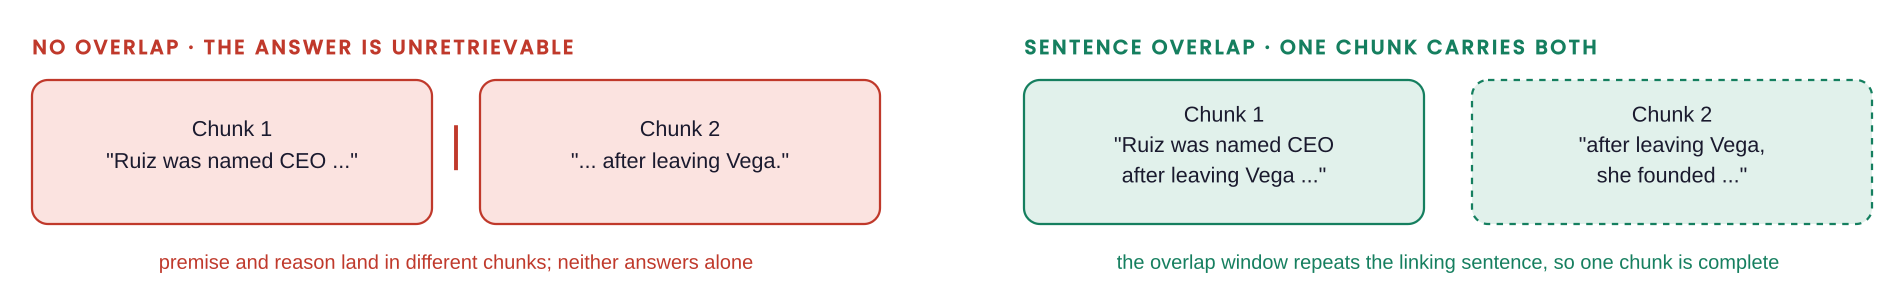

*The cell below reproduces this on an eight-word fact that a 28-word window happens to split; the grid above showed the loss at overlap 0 and its repair at overlap 4.*

In [5]:
q04 = next(q for q in questions if q.qid == "q04")
b7 = store.doc("b7"); span = q04.gold[1][1]
print("the fact:", span, f"({len(span.split())} words)\n")
for ov in [0, 4]:
    cc = rk.fixed_words(b7, 28, ov)
    carrier = [c.chunk_id for c in cc if " ".join(span.split()) in " ".join(c.text.split())]
    print(f"fixed 28 words, overlap {ov}: {len(cc)} chunks, carrier = {carrier or 'NONE, boundary loss'}")
    for c in cc[:2]:
        print(f"   {c.chunk_id}: {c.text[:95]}...")
    print()

the fact: The initial public offering raised 310 million dollars (8 words)

fixed 28 words, overlap 0: 4 chunks, carrier = NONE, boundary loss
   b7:0:3b7a2061: Shares of Vega Dynamics rose 28 percent in their Nasdaq debut on Thursday, June 8, 2023, valuin...
   b7:1:a0c35a55: offering raised 310 million dollars and the stock trades under the ticker VGDN. Chief executive...

fixed 28 words, overlap 4: 5 chunks, carrier = ['b7:1:7b31420a']
   b7:0:3b7a2061: Shares of Vega Dynamics rose 28 percent in their Nasdaq debut on Thursday, June 8, 2023, valuin...
   b7:1:7b31420a: dollars. The initial public offering raised 310 million dollars and the stock trades under the ...



## 4 · Right document, wrong chunk: what carrying the title does

Structural chunking here prefixes every chunk with its document title. That lifts recall for chunks that never name their subject, and it makes every chunk of a document look alike, so the retriever can rank a sibling above the chunk that carries the fact. Both effects are measurable.

In [6]:
anchor = rk.ANCHOR
rows = []
for label, chunker in [("title carried", "structural"), ("raw paragraphs", "structural_raw")]:
    ch, ret = build(chunker, f"tc_{label[:3]}")
    ids = [cid for cid, _ in ret.hybrid(anchor.text, k=64)]
    gs = rk.gold_chunk_sets(anchor, ch)
    ranks = {sorted(s)[0].split(":")[0]: ids.index(sorted(s)[0]) + 1 for s in gs}
    best = {d: min(i + 1 for i, c in enumerate(ids) if c.startswith(d + ":")) for d in ["a1", "b7"]}
    a1 = [c.chunk_id for c in ch if c.doc_id == "a1"]
    sib = ret.flat.cosine(a1[0], a1[1])
    rows.append({"chunking": label, "a1 gold chunk rank": ranks["a1"], "best a1 chunk rank": best["a1"], "b7 gold chunk rank": ranks["b7"], "best b7 chunk rank": best["b7"], "cosine of a1 siblings": round(sib, 3)})
table(pd.DataFrame(rows), "The worked question under both variants, hybrid over all chunks")

chunking,a1 gold chunk rank,best a1 chunk rank,b7 gold chunk rank,best b7 chunk rank,cosine of a1 siblings
title carried,7,2,19,3,0.333
raw paragraphs,9,5,17,3,0.021


| What you saw | The lesson |
|---|---|
| In both variants a sibling outranks the gold chunk, because the second paragraph of the IPO article really does mention Ruiz taking the company public. | Document-level relevance and chunk-level relevance are different questions, and top-k answers only the second. |
| Carrying the title pushes sibling similarity from about 0.02 to about 0.33, so the retriever sees a document's chunks as near-duplicates. | Carried context trades chunk-level precision for document-level recall. It is a trade, not a free improvement, and dedup before packing in notebook 05 is the other half of it. |
| With raw paragraphs, a chunk that never names its subject is harder to reach at all: the a1 gold chunk drops two places. | Some context per chunk is needed; the question is how much and of what kind, which is what contextual retrieval in section 8 measures. |

## 5 · Query-time: retrieve, pack, answer, and always trace

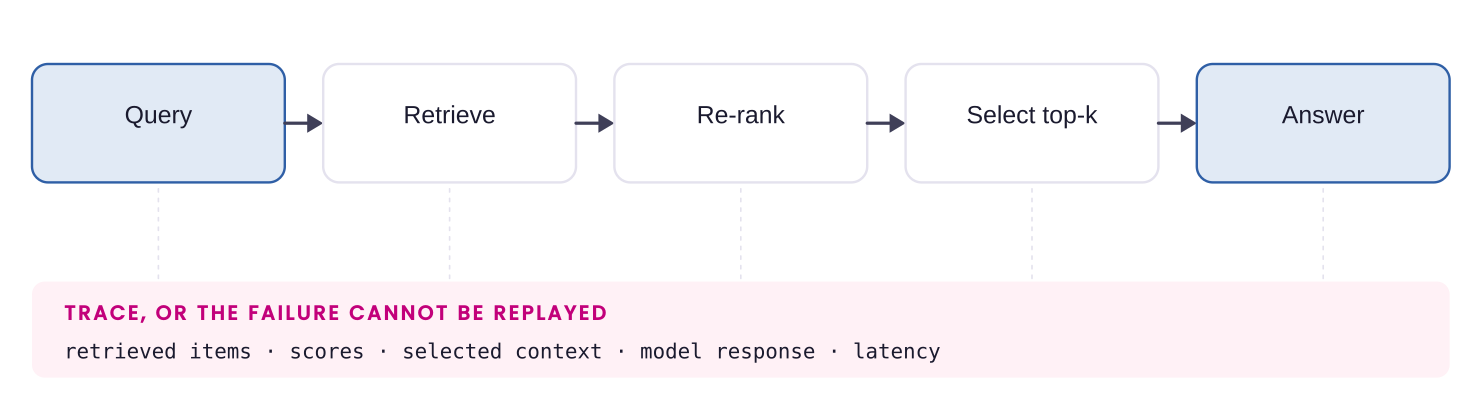

*The trace is the audit record. The cell writes one to the store and reads it back.*

In [7]:
ch, ret = systems["structural"]
texts = {c.chunk_id: c.text for c in ch}
pool = ret.hybrid(anchor.text, k=50)
packed = rk.pack(pool, texts, evidence_cap=6000, k=5)
ans = rk.MockGenerator().answer(anchor, packed.chunk_ids, texts)
store.save_trace("demo:q01", anchor.text, {"config": "structural hybrid k5", "pool": [c for c, _ in pool], "scores": [round(s, 4) for _, s in pool[:10]],
                                          "packed": packed.chunk_ids, "dropped": packed.dropped[:5], "answer": ans.text, "citations": ans.citations, "evidence_tokens": packed.tokens})
rk.show_trace(store, "demo:q01")
table(store.sql("SELECT trace_id, question, length(payload) AS payload_bytes FROM traces"), "The traces table")

trace demo:q01
config: structural hybrid k5
packed (5): ['g2:0:7465c618', 'a1:2:8d2011b6', 'b7:1:eb0b8d13', 'g2:1:759cdda7', 'k3:1:3ea2bfbe']
dropped: [['r1:0:7e49a71b', 'over k'], ['a1:0:63d9a4f8', 'over k'], ['l3:1:b31c0299', 'over k'], ['g1:0:ab5b7020', 'over k'], ['b7:2:d1f9f0e4', 'over k']]
answer: INSUFFICIENT EVIDENCE. None of the required facts are in the evidence.


trace_id,question,payload_bytes
demo:q01,"The person who became CEO of Nord Aerospace in 2026 had earlier taken which company public, and in what year?",1366


| A trace must record | So that you can |
|---|---|
| The ranked candidate pool with scores. | Answer Q2 of the fault tree: was the gold chunk in the pool at all. |
| The packed chunk ids, in the order packed, and what was dropped with the reason. | Answer Q1 and diagnose packing and ordering faults. |
| The exact answer text and its citations. | Score faithfulness later, and replay the generation with a different model. |
| Token counts and latency per stage. | Attribute cost and p95 to a stage rather than to the request. |

## 6 · Keeping the index fresh without a nightly full rebuild

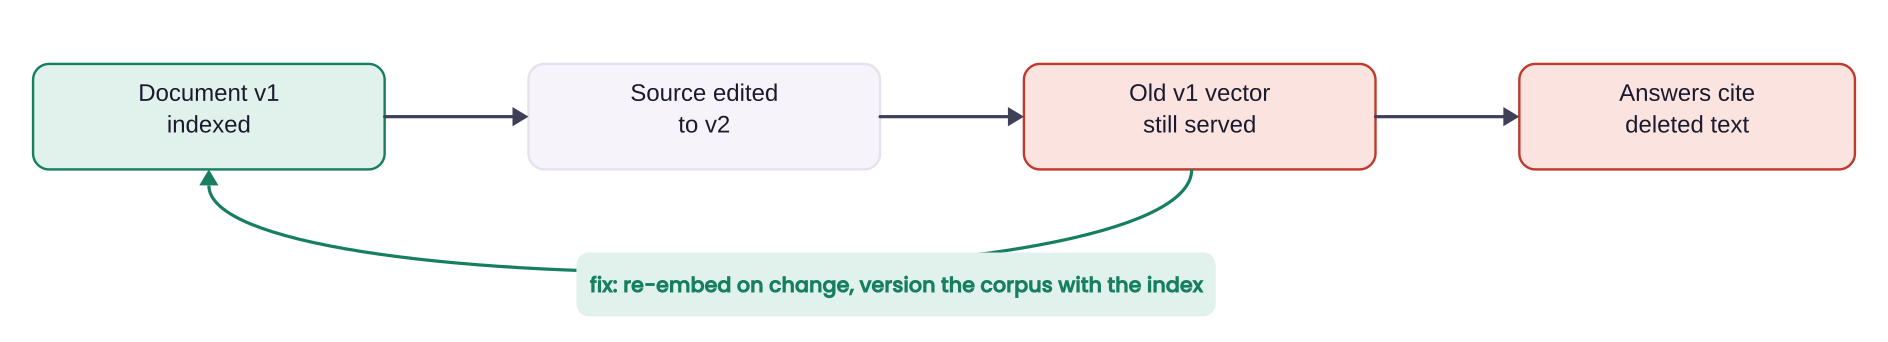

*The state machine from the session deck. The cell walks every transition.*

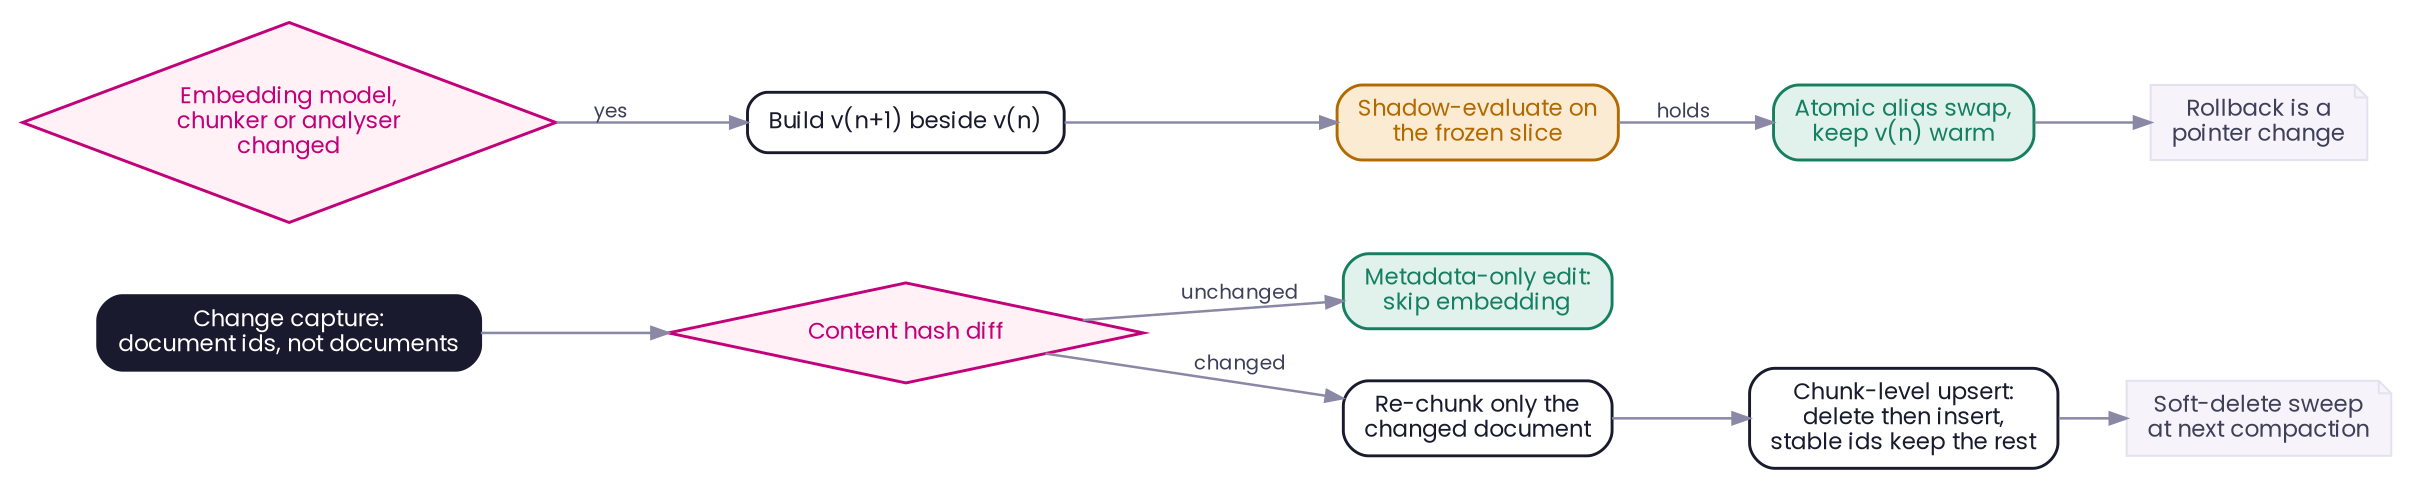

*Incremental path in minutes, rebuild path in hours. Taken from the advanced-track deck. Never mix the two paths.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    cdc(["Change capture:<br/>document ids, not documents"])
    hash{"Content hash diff"}
    skip["Metadata-only edit:<br/>skip embedding"]
    rech["Re-chunk only the<br/>changed document"]
    ups["Chunk-level upsert:<br/>delete then insert,<br/>stable ids keep the rest"]
    tomb["Soft-delete sweep<br/>at next compaction"]
    model{"Embedding model,<br/>chunker or analyser<br/>changed"}
    v2["Build v(n+1) beside v(n)"]
    shadow["Shadow-evaluate on<br/>the frozen slice"]
    swap["Atomic alias swap,<br/>keep v(n) warm"]
    back["Rollback is a<br/>pointer change"]
    cdc --> hash
    hash -->|unchanged| skip
    hash -->|changed| rech
    rech --> ups
    ups --> tomb
    model -->|yes| v2
    v2 --> shadow
    shadow -->|holds| swap
    swap --> back
    class cdc start
    class hash dec
    class skip ok
    class tomb note
    class model dec
    class shadow cost
    class swap ok
    class back note
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [8]:
live = store.live_version()
before = {c.chunk_id for c in store.chunks(live)}

# (a) a metadata-only edit: the normalised body hash is unchanged, so nothing is re-embedded
changed = store.update_doc_body("a1", store.doc("a1").body)
print("(a) metadata-only edit changed the body hash:", changed, "-> skip re-chunking")

# (b) a content edit: only a1 is re-chunked, and stable ids show which chunks survived
new_body = store.doc("a1").body.replace("about 1,400 people", "about 1,500 people")   # one number in the last paragraph
changed = store.update_doc_body("a1", new_body)
new_chunks = rk.structural(store.doc("a1"), version=live)
store.delete_chunks_for_doc("a1", live); store.add_chunks(new_chunks, live)
after = {c.chunk_id for c in store.chunks(live)}
print("(b) content edit changed the hash:", changed, "| a1 chunks that kept their ids:", sorted(before & {c.chunk_id for c in new_chunks}))
print("    new chunk id(s):", sorted(after - before), "| retired id(s):", sorted(before - after), "| the two unchanged paragraphs were never re-embedded")

# (c) the rebuild path: a new embedding configuration becomes a new version beside the live one
frozen = [q for q in questions if q.frozen]
ch_v1, ret_v1 = build("structural", "v1")
ch_v2, ret_v2 = build("structural", "v2", n_components=24, random_state=1)
shadow = pd.DataFrame({v: validate(ch, ret, frozen, k=10) for v, (ch, ret) in {"v1 (live)": (ch_v1, ret_v1), "v2 (shadow)": (ch_v2, ret_v2)}.items()}).T.reset_index().rename(columns={"index": "version"})
display(table(shadow, "(c) Shadow evaluation of v2 on the frozen slice before any traffic moves"))
if shadow.loc[1, "full_chain@10"] >= shadow.loc[0, "full_chain@10"]:
    store.set_live("v2"); print("    v2 holds on the frozen slice: alias swapped, live =", store.live_version())
store.set_live("v1"); print("    rollback is a pointer change, live =", store.live_version())

(a) metadata-only edit changed the body hash: False -> skip re-chunking
(b) content edit changed the hash: True | a1 chunks that kept their ids: ['a1:0:63d9a4f8', 'a1:1:aca89706']
    new chunk id(s): ['a1:2:0e1e4b24'] | retired id(s): ['a1:2:8d2011b6'] | the two unchanged paragraphs were never re-embedded


version,chunks,boundary_loss_spans,full_chain@10,correct
v1 (live),64.000,0.000,1.000,1.000
v2 (shadow),64.000,0.000,1.000,1.000


    v2 holds on the frozen slice: alias swapped, live = v2
    rollback is a pointer change, live = v1


In [9]:
# (d) the outage: vectors from two embedding models in one index. Cosine still returns a number; it just means nothing.
ids = [c.chunk_id for c in ch_v1]; tx = [c.text for c in ch_v1]
A = rk.LSAEmbedder(24, 0).fit(tx); B = rk.LSAEmbedder(24, 1).fit(tx[::2])   # same dimensionality, different spaces
half = len(ids) // 2
mixed = np.vstack([A.embed(tx[:half]), B.embed(tx[half:])])       # first half from model A, second half from model B
clean = A.embed(tx)
def recall_with(index, embedder, k=5):
    hits = []
    for q in [x for x in questions if x.gold]:
        got = [cid for cid, _ in index.search(embedder.embed_one(q.text), k=k)]
        hits.append(rk.evidence_recall_at_k(rk.gold_chunk_sets(q, ch_v1), got, k))
    return round(float(np.mean(hits)), 3)
res = pd.DataFrame([{"index": "clean, one model", "span recall@5": recall_with(rk.FlatIndex(ids, clean), A)},
                    {"index": "mixed, two models", "span recall@5": recall_with(rk.FlatIndex(ids, mixed), A)}])
table(res, "(d) Dense span recall at k=5 with the query embedded by model A")

index,span recall@5
"clean, one model",0.889
"mixed, two models",0.500


| Transition | The rule | The failure it prevents |
|---|---|---|
| Change capture emits document ids, not documents. | Diff the normalised body hash; a metadata-only edit never re-embeds. | Paying embedding cost for edits that changed nothing the retriever sees. |
| Content changed. | Re-chunk that document only, delete then insert, and let stable ids keep the unchanged chunks. | Orphaned chunks that still match old text, and a full-corpus re-embed for one edit. |
| Embedding model, chunker or analyser changed. | Build the new version beside the live one, shadow-evaluate on the frozen slice, then swap the alias. | Serving a worse index because nobody measured it before routing. |
| Rollback. | A pointer change back to the warm previous version. | A rebuild under pressure. |
| Two models' vectors in one index. | Never. Vectors from different models are not comparable, and cosine will not tell you they are wrong. | The recall collapse in (d), which every downstream metric would attribute to something else. |

## 7 · Permission-aware retrieval: filter before ranking, never after

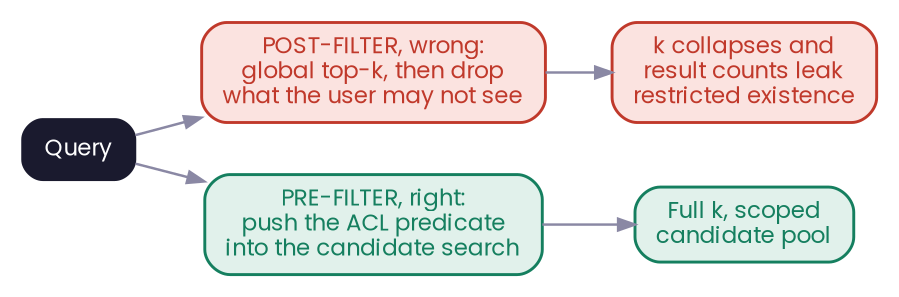

*From the advanced-track deck. Post-filtering is the leak.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    q(["Query"])
    post["POST-FILTER, wrong:<br/>global top-k, then drop<br/>what the user may not see"]
    k["k collapses and<br/>result counts leak<br/>restricted existence"]
    pre["PRE-FILTER, right:<br/>push the ACL predicate<br/>into the candidate search"]
    full["Full k, scoped<br/>candidate pool"]
    q --> post
    post --> k
    q --> pre
    pre --> full
    class q start
    class post fail
    class k fail
    class pre ok
    class full ok
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

path,results returned,internal docs in results
"global top-5, no filter",5,3
post-filter for a public user,2,0
pre-filter for a public user,5,0
pre-filter for an engineer,5,3


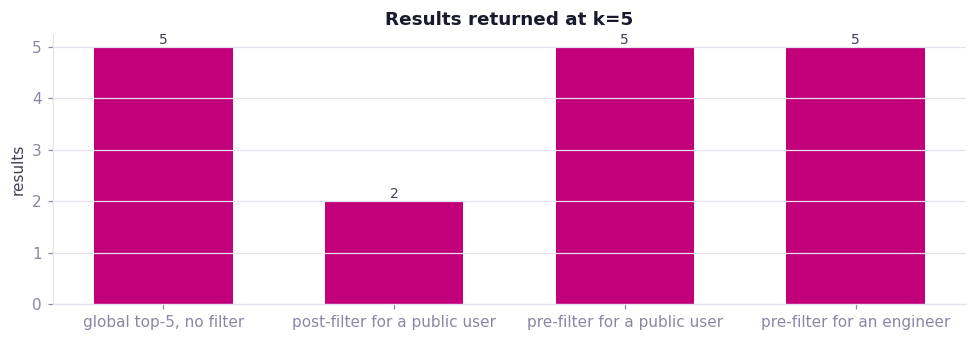

In [10]:
ch, ret = systems["structural"]
q = "fix for the fleet manager error and the Kestrel engine chamber pressure"
public_user = ["everyone"]
engineer = ["everyone", "halden-engineering", "vega-engineering"]
global_top = ret.hybrid(q, k=5)
post = ret.post_filtered(q, k=5, mode="hybrid", user_groups=public_user)
pre = ret.hybrid(q, k=5, user_groups=public_user)
eng = ret.hybrid(q, k=5, user_groups=engineer)
summary = pd.DataFrame([{"path": "global top-5, no filter", "results returned": len(global_top), "internal docs in results": sum(1 for c, _ in global_top if c.split(":")[0] in {"g3", "h5"})},
                        {"path": "post-filter for a public user", "results returned": len(post), "internal docs in results": 0},
                        {"path": "pre-filter for a public user", "results returned": len(pre), "internal docs in results": 0},
                        {"path": "pre-filter for an engineer", "results returned": len(eng), "internal docs in results": sum(1 for c, _ in eng if c.split(":")[0] in {"g3", "h5"})}])
display(table(summary, "The same query, k=5, for two users"))
bars(list(summary["path"]), list(summary["results returned"]), "Results returned at k=5", "results", fmt="{:.0f}", figsize=(9, 3.2))

| Design question | The answer that does not leak | Why |
|---|---|---|
| Where does the access list live at query time? | On the chunk, denormalised, with its own change stream for revocations. | A per-request call to the source system is too slow for the candidate search, and a stale list is a leak. |
| Filter or namespace per tenant? | Namespaces isolate cleanly and cost cross-tenant recall; filters share an index and cost tuning. Choose by whether cross-tenant search is ever legitimate. | A very selective filter can strand a graph index's traversal, which notebook 04 discusses with the ANN matrix. |
| Is the prompt cache tenant-scoped? | It must be. | A shared prefix cache across tenants is a data-leak class of bug, revisited in notebook 07. |
| Do traces store retrieved text? | If yes, the trace store inherits the corpus's compliance boundary. | The trace from section 5 contains chunk text. |

## 8 · Contextual retrieval, reproduced on this corpus

Anthropic's contextual retrieval prepends a short document-derived context to each chunk before embedding and before lexical indexing. Their measured result, verified against the write-up: top-20 retrieval failures fall from 5.7 percent to 3.7 percent with contextual embeddings, to 2.9 percent adding contextual BM25, and to 1.9 percent adding a reranker, a 67 percent reduction. Below, the same ladder is climbed on this corpus. The numbers are ours, on 30 documents, and are not comparable to theirs; the shape is the point.

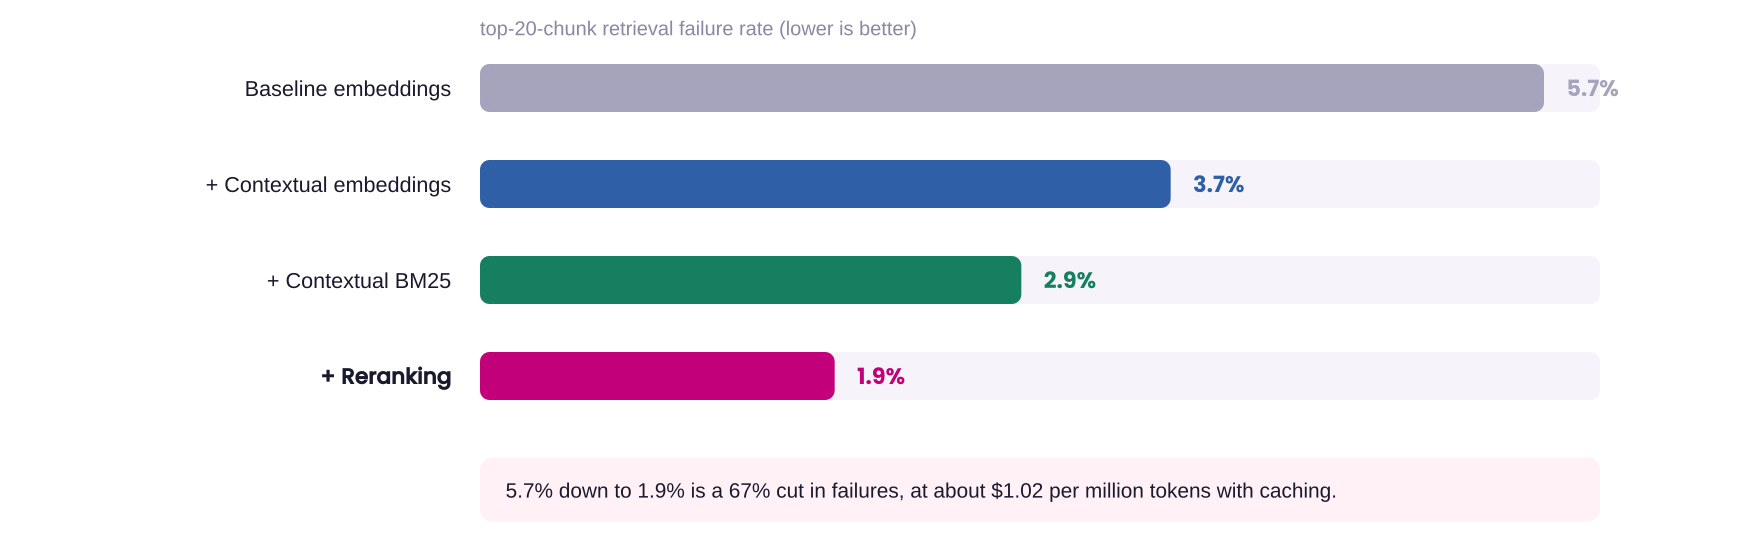

*Verified against the contextual retrieval write-up.*

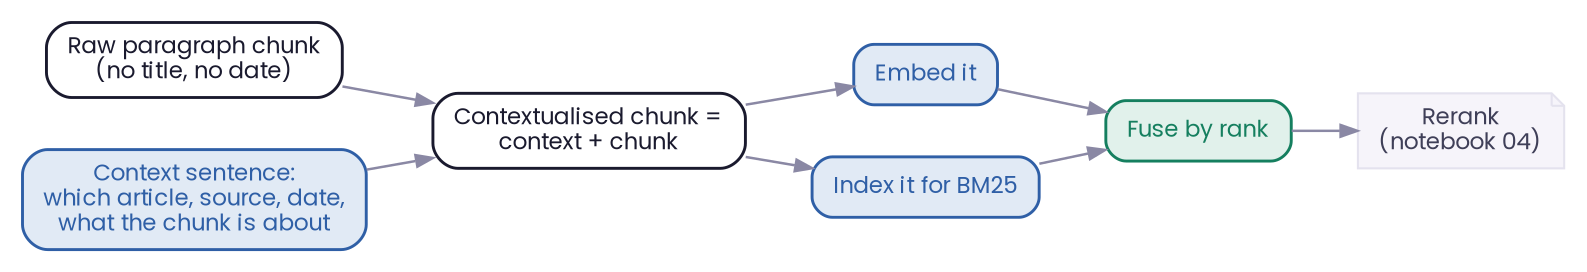

*Offline, the context sentence is built from metadata. With a provider configured, the cell asks the model to write it from the whole document, which is what the original method does.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    raw["Raw paragraph chunk<br/>(no title, no date)"]
    ctx["Context sentence:<br/>which article, source, date,<br/>what the chunk is about"]
    cat["Contextualised chunk =<br/>context + chunk"]
    emb["Embed it"]
    bm["Index it for BM25"]
    fuse["Fuse by rank"]
    rr["Rerank<br/>(notebook 04)"]
    raw --> cat
    ctx --> cat
    cat --> emb
    cat --> bm
    emb --> fuse
    bm --> fuse
    fuse --> rr
    class ctx tool
    class emb tool
    class bm tool
    class fuse ok
    class rr note
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

example contextualised chunk:
   This passage is from the article Nord Aerospace names Elena Ruiz chief executive (TechCrunch, 2026-03-12). Nord Aerospace, the Bergen-based launch-vehicle maker, named Elena Ruiz as chief executive on ...


step,top-5 failure %
"baseline: raw chunks, dense only",16.700
+ contextual embeddings,11.100
"+ contextual BM25, fused",11.100


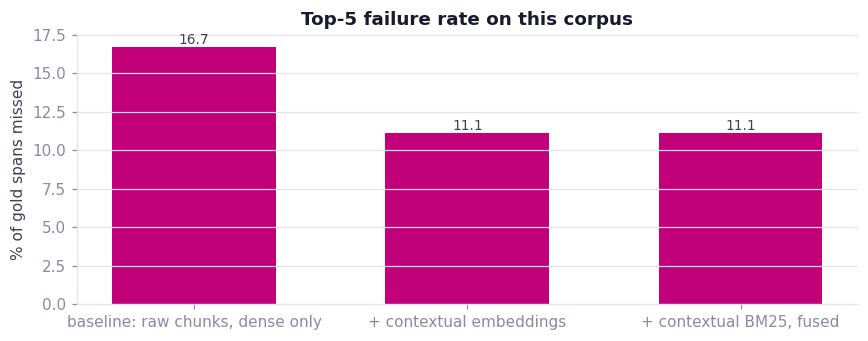

In [11]:
def context_sentence(doc, chunk_text):
    """Offline: a metadata-derived context. With a provider: the model writes it from the whole document."""
    if rk.config()["provider"] != "mock":
        prompt = f"<document>\n{doc.text}\n</document>\nHere is a chunk from that document:\n<chunk>\n{chunk_text}\n</chunk>\nWrite one short sentence situating this chunk within the document, naming the company, the event and the date, to improve search retrieval. Answer with the sentence only."
        return rk.get_llm().generate(prompt).strip()
    return f"This passage is from the article {doc.title} ({doc.source}, {doc.date})."

raw = [c for d in docs for c in rk.structural(d, carry_title=False, version="raw")]
ctx = [rk.Chunk(c.chunk_id, c.doc_id, c.ordinal, context_sentence(store.doc(c.doc_id), c.text) + " " + c.text, c.heading, "ctx") for c in raw]
print("example contextualised chunk:\n  ", ctx[0].text[:200], "...")

def failure_rate(chunks, mode, k=5):
    _, ret_ = build(chunks=chunks, version=f"ctx_{mode}_{len(chunks)}")
    miss = []
    for q in [x for x in questions if x.gold]:
        ids = [cid for cid, _ in ret_.search(q.text, k=k, mode=mode)]
        miss.append(1 - rk.evidence_recall_at_k(rk.gold_chunk_sets(q, chunks), ids, k))
    return round(100 * float(np.mean(miss)), 1)

ladder = pd.DataFrame([{"step": "baseline: raw chunks, dense only", "top-20 failure %": failure_rate(raw, "dense")},
                       {"step": "+ contextual embeddings", "top-20 failure %": failure_rate(ctx, "dense")},
                       {"step": "+ contextual BM25, fused", "top-20 failure %": failure_rate(ctx, "hybrid")}])
ladder.columns = ["step", "top-5 failure %"]
display(table(ladder, "Retrieval failure rate at top-5 on this corpus (ours, 9 answerable questions, 2 spans each). Top-20 would be a third of the corpus, so top-5 is the comparable cut here."))
bars(list(ladder["step"]), list(ladder["top-5 failure %"]), "Top-5 failure rate on this corpus", "% of gold spans missed", fmt="{:.1f}", figsize=(8, 3.2))

| Step | Anthropic, verified | This corpus, measured above | What the step adds |
|---|---|---|---|
| Baseline embeddings | 5.7 percent failures | 16.7 percent | The chunk alone, with nothing to say which company or period it belongs to. |
| Contextual embeddings | 3.7 percent | 11.1 percent | The context sentence gives the vector the missing entity and date, and a third of the misses disappear. |
| Contextual BM25, fused | 2.9 percent | 11.1 percent, no further gain | Offline, the context sentence is the same for every chunk of a document, so BM25 gains entity terms but nothing that tells siblings apart. The original method writes a chunk-specific context, and that is where its lexical gain comes from. With a provider configured, this cell does the same. |
| Reranking | 1.9 percent, a 67 percent cut overall | notebook 04 | Reorders the fused pool with a model that reads query and passage together. |

| If | Then | Because |
|---|---|---|
| The knowledge base is under roughly 200,000 tokens. | Put the whole thing in the model context and skip retrieval, as the write-up itself recommends. | At that size retrieval adds cost and failure modes for no recall benefit. The next cell runs that decision on this corpus. |
| The base is large and queries target facts buried in chunks that do not name their subject. | Contextualise chunks, index both ways, then rerank. | This is the regime where the measured cut applies. |
| Contextualising every chunk is expensive. | Cache the document prefix so the contextualisation call pays for the document once, not per chunk. | Anthropic reports about one dollar per million document tokens with caching. Notebook 07 costs it. |

In [12]:
corpus_tokens = sum(rk.count_tokens(d.text) for d in docs)
SKIP_TREE = [
    {"q": "Is the whole knowledge base under about 200,000 tokens?", "test": lambda f: f["corpus_tokens"] < 200_000,
     "yes": "put the whole corpus in the context window and skip retrieval; keep the benchmark to prove it still answers", "no": None, "show": lambda f: f"corpus_tokens={f['corpus_tokens']:,}"},
    {"q": "Do queries target facts buried in chunks that do not name their subject?", "test": lambda f: f["buried"], "yes": "contextual retrieval, both indexes, then rerank", "no": "plain hybrid retrieval with structural chunks", "show": lambda f: f"buried={f['buried']}"},
]
table(decision(SKIP_TREE, {"corpus_tokens": corpus_tokens, "buried": True}), "Executed on this corpus. The 200k rule is from the contextual retrieval write-up.")

question,measured,answer
"Is the whole knowledge base under about 200,000 tokens?","corpus_tokens=2,155",yes
Outcome,,put the whole corpus in the context window and skip retrieval; keep the benchmark to prove it still answers


## What to carry out of this notebook

| # | The line worth remembering |
|---|---|
| 1 | The index is a product decision, because its structure sets the outer limit of what any query can ever find; validate it on the benchmark before it goes live. |
| 2 | A chunk shorter than the fact loses the fact at every overlap; a boundary inside the fact is repaired by overlap; structure beats windows when the documents have any. |
| 3 | Carrying the title into every chunk lifts document recall and blurs chunk precision, which is a trade you measure, not a default. |
| 4 | Keep the index fresh with hash diffs and chunk-level upserts, rebuild only for a model or chunker change, swap by alias, and never mix two models' vectors. |
| 5 | Filter before ranking. Post-filtering collapses k and leaks the existence of restricted documents through result counts. |
| 6 | Contextualising chunks lifts both indexes; below about 200,000 tokens the right move is often to skip retrieval entirely. |

**Next: 04 · Retrieval methods and reranking.** The index is built. Notebook 04 tunes query time over it: BM25 internals, the geometry of cosine, flat against IVF with the recall knob, hybrid fusion, and the two reranker families that climb the fourth rung of the ladder above.

## Interview corner

| Question an interviewer may ask | What a strong answer does | Red flag |
|---|---|---|
| Design a RAG pipeline for documents that change daily. | Says versioned index, hash-diff incremental upserts with stable chunk ids, blue-green swap, shadow evaluation on a frozen slice. | Proposes a nightly full rebuild as the whole answer. |
| Legal requires that no answer can be influenced by a document the user cannot read. Design it. | Puts the ACL predicate into the candidate search, scopes the prompt cache per tenant, and treats the trace store as inside the compliance boundary. | Filters after retrieval. |
| How would you choose chunk size for legal contracts? | Reasons from the failure mode, boundary loss on long clauses, measures a size-by-overlap grid, and prefers structural boundaries. | Quotes a default number. |